# Figures & Comparison: Beating MAPS on cHL CODEX

This notebook generates publication-quality figures:
1. **Method Comparison** — Bar chart comparing ASTIR, CellSighter, MAPS, and Our Ensemble
2. **Methodology Illustration** — Pipeline diagram of our stacking ensemble approach
3. **Spatial Cell Map** — All cells in the dataset coloured by cell type

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
print('Ready')

Ready


## 1. Method Comparison — Weighted F1 Scores

Reported F1 scores on the cHL CODEX dataset:
- **ASTIR**: 0.61
- **CellSighter**: 0.82
- **MAPS** (5-fold ensemble): 0.897
- **Ours** (Stacking Ensemble, 5-fold CV pooled): 0.9027

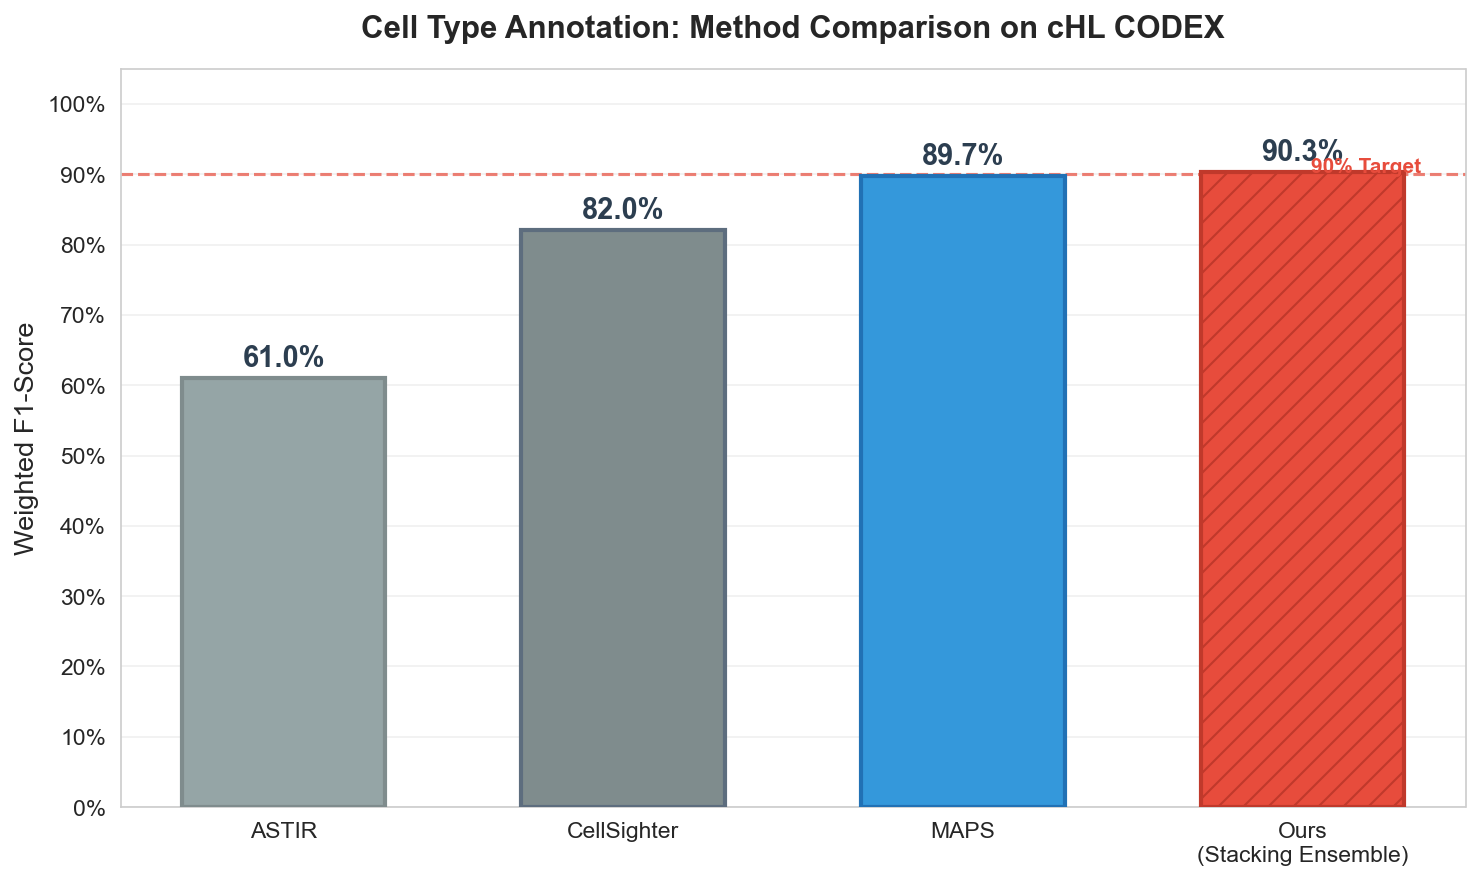

Saved: figures_method_comparison.png


In [7]:
# ====================================================================
# FIGURE 1: Method Comparison Bar Chart
# ====================================================================
methods = ['ASTIR', 'CellSighter', 'MAPS', 'Ours\n(Stacking Ensemble)']
scores  = [0.61, 0.82, 0.897, 0.9027]
colors  = ['#95a5a6', '#7f8c8d', '#3498db', '#e74c3c']
edge_c  = ['#7f8c8d', '#5d6d7e', '#2171b5', '#c0392b']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(methods, scores, color=colors, edgecolor=edge_c,
              linewidth=2, width=0.6, zorder=3)

# Annotate bars with values
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{score:.1%}', ha='center', va='bottom', fontweight='bold',
            fontsize=14, color='#2c3e50')

# 90% target line
ax.axhline(y=0.90, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
ax.text(3.35, 0.903, '90% Target', color='#e74c3c', fontsize=10,
        fontweight='bold', ha='right')

ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_title('Cell Type Annotation: Method Comparison on cHL CODEX',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.grid(axis='x', visible=False)

# Highlight the winner
bars[-1].set_hatch('//')

plt.tight_layout()
plt.savefig('figures_method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures_method_comparison.png')

## 2. Methodology Illustration — Stacking Ensemble Pipeline

Visual diagram of our approach that beat MAPS.

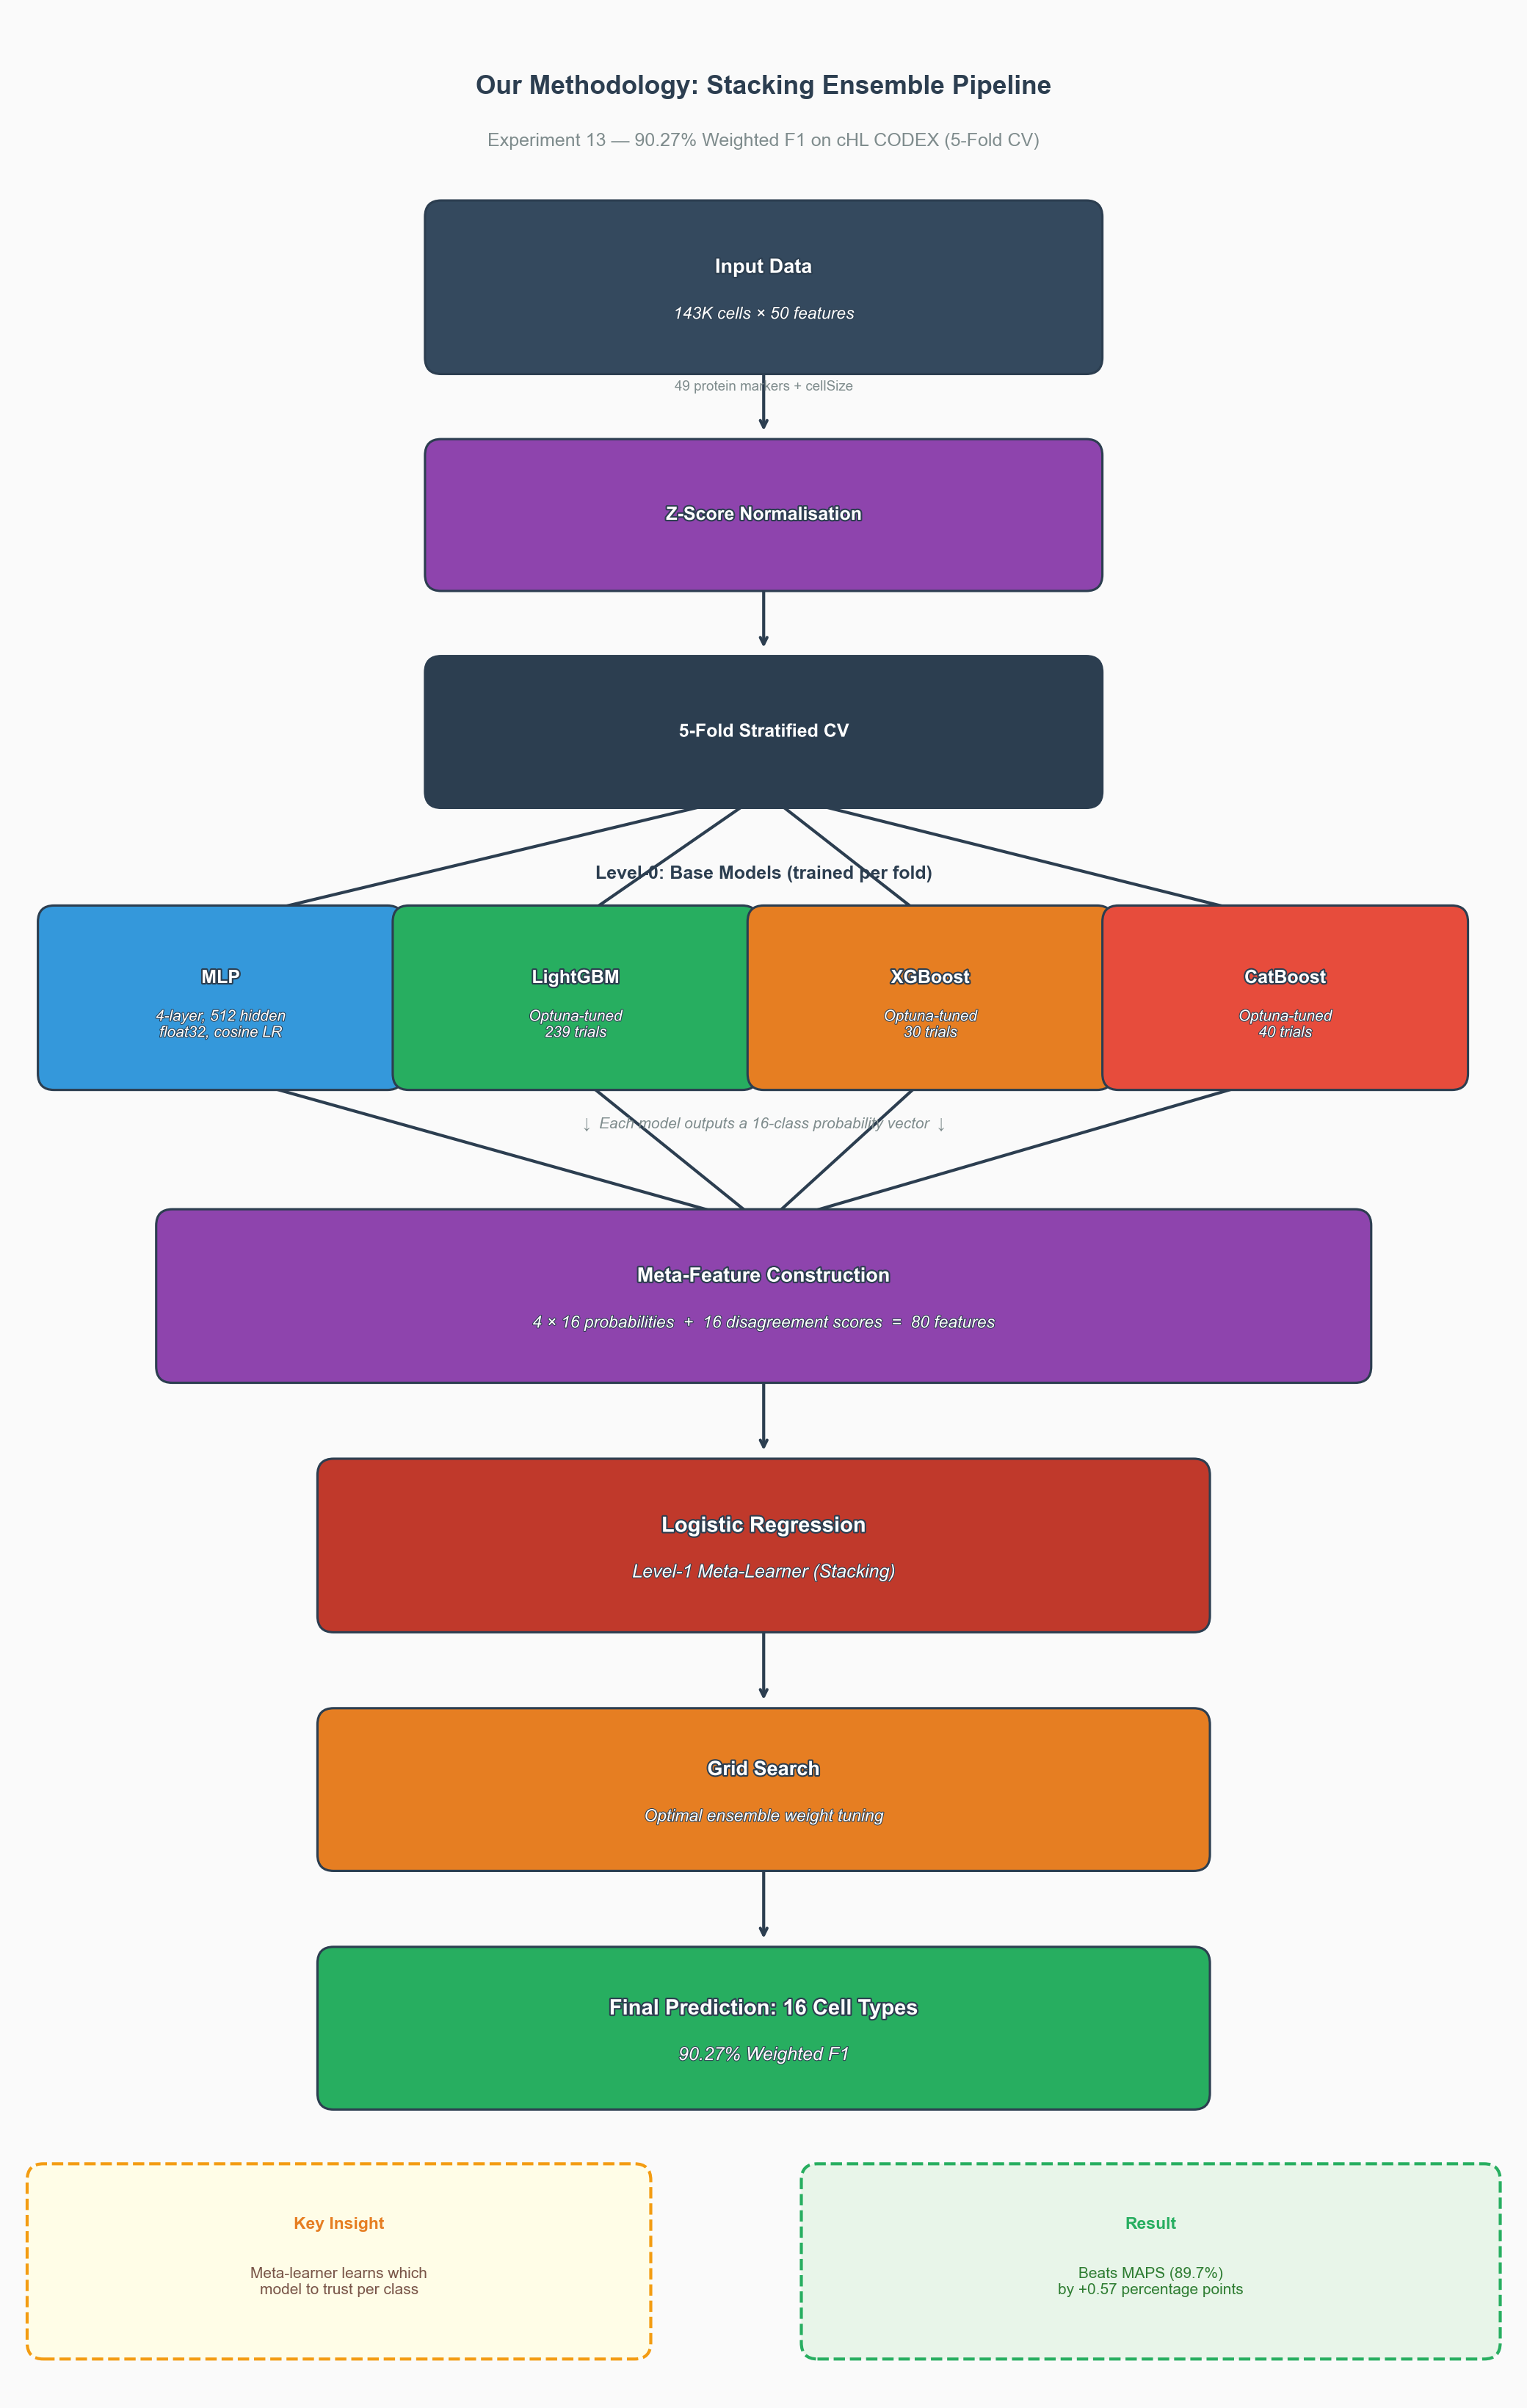

Saved: figures_methodology_pipeline.png


In [8]:
# ====================================================================
# FIGURE 2: Methodology Pipeline Illustration (Vertical Top-to-Bottom)
# ====================================================================
fig, ax = plt.subplots(figsize=(14, 22))
ax.set_xlim(0, 14)
ax.set_ylim(0, 22)
ax.axis('off')
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('#fafafa')

# --- Helper functions ---
def draw_box(ax, xy, w, h, label, color, fontsize=10, sublabel=None):
    box = FancyBboxPatch(xy, w, h, boxstyle='round,pad=0.15',
                         facecolor=color, edgecolor='#2c3e50',
                         linewidth=1.5, zorder=3)
    ax.add_patch(box)
    cx, cy = xy[0] + w/2, xy[1] + h/2
    if sublabel:
        ax.text(cx, cy + 0.18, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color='white',
                path_effects=[pe.withStroke(linewidth=2, foreground='#2c3e50')], zorder=4)
        ax.text(cx, cy - 0.25, sublabel, ha='center', va='center',
                fontsize=fontsize-2, color='white', style='italic',
                path_effects=[pe.withStroke(linewidth=1, foreground='#2c3e50')], zorder=4)
    else:
        ax.text(cx, cy, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color='white',
                path_effects=[pe.withStroke(linewidth=2, foreground='#2c3e50')], zorder=4)
    return box

def draw_arrow(ax, start, end, color='#2c3e50'):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=2, connectionstyle='arc3,rad=0'),
                zorder=2)

# ====================================================================
# TITLE (top)
# ====================================================================
ax.text(7, 21.3, 'Our Methodology: Stacking Ensemble Pipeline',
        ha='center', va='center', fontsize=17, fontweight='bold', color='#2c3e50')
ax.text(7, 20.8, 'Experiment 13 — 90.27% Weighted F1 on cHL CODEX (5-Fold CV)',
        ha='center', va='center', fontsize=12, color='#7f8c8d')

# ====================================================================
# STAGE 1: Input Data (centered)
# ====================================================================
draw_box(ax, (4, 18.8), 6, 1.3, 'Input Data', '#34495e', fontsize=13,
         sublabel='143K cells × 50 features')
ax.text(7, 18.5, '49 protein markers + cellSize', ha='center',
        fontsize=9, color='#7f8c8d')

# Arrow ↓
draw_arrow(ax, (7, 18.8), (7, 18.1))

# ====================================================================
# STAGE 2: Z-Score Normalisation (centered)
# ====================================================================
draw_box(ax, (4, 16.8), 6, 1.1, 'Z-Score Normalisation', '#8e44ad', fontsize=12)

# Arrow ↓
draw_arrow(ax, (7, 16.8), (7, 16.1))

# ====================================================================
# STAGE 3: 5-Fold Stratified CV (centered)
# ====================================================================
draw_box(ax, (4, 14.8), 6, 1.1, '5-Fold Stratified CV', '#2c3e50', fontsize=12)

# ====================================================================
# STAGE 4: Level-0 label
# ====================================================================
ax.text(7, 14.0, 'Level-0: Base Models (trained per fold)',
        ha='center', fontsize=12, fontweight='bold', color='#2c3e50')

# Fan-out arrows from CV to 4 models
model_info = [
    ('MLP',      '#3498db', '4-layer, 512 hidden\nfloat32, cosine LR', 0.4),
    ('LightGBM', '#27ae60', 'Optuna-tuned\n239 trials',                3.7),
    ('XGBoost',  '#e67e22', 'Optuna-tuned\n30 trials',                 7.0),
    ('CatBoost', '#e74c3c', 'Optuna-tuned\n40 trials',                10.3),
]

for name, color, details, x_pos in model_info:
    draw_box(ax, (x_pos, 12.2), 3.1, 1.4, name, color, fontsize=12,
             sublabel=details)
    # Arrow from CV bottom-center to each model top-center
    draw_arrow(ax, (7, 14.8), (x_pos + 1.55, 13.6))

# ====================================================================
# STAGE 5: Probability output label
# ====================================================================
ax.text(7, 11.7, '↓  Each model outputs a 16-class probability vector  ↓',
        ha='center', fontsize=10, color='#7f8c8d', style='italic')

# Arrows from each model down to meta-feature box
for name, color, details, x_pos in model_info:
    draw_arrow(ax, (x_pos + 1.55, 12.2), (7, 10.8))

# ====================================================================
# STAGE 6: Meta-Feature Construction (wide, centered)
# ====================================================================
draw_box(ax, (1.5, 9.5), 11, 1.3, 'Meta-Feature Construction', '#8e44ad', fontsize=13,
         sublabel='4 × 16 probabilities  +  16 disagreement scores  =  80 features')

# Arrow ↓
draw_arrow(ax, (7, 9.5), (7, 8.7))

# ====================================================================
# STAGE 7: Level-1 Meta-Learner (centered)
# ====================================================================
draw_box(ax, (3, 7.2), 8, 1.3, 'Logistic Regression', '#c0392b', fontsize=14,
         sublabel='Level-1 Meta-Learner (Stacking)')

# Arrow ↓
draw_arrow(ax, (7, 7.2), (7, 6.4))

# ====================================================================
# STAGE 8: Grid Search Weight Optimisation (centered)
# ====================================================================
draw_box(ax, (3, 5.0), 8, 1.2, 'Grid Search', '#e67e22', fontsize=13,
         sublabel='Optimal ensemble weight tuning')

# Arrow ↓
draw_arrow(ax, (7, 5.0), (7, 4.2))

# ====================================================================
# STAGE 9: Final Output (centered)
# ====================================================================
draw_box(ax, (3, 2.8), 8, 1.2, 'Final Prediction: 16 Cell Types', '#27ae60',
         fontsize=14, sublabel='90.27% Weighted F1')

# ====================================================================
# Key Insight callout (bottom-right)
# ====================================================================
callout = FancyBboxPatch((0.3, 0.5), 5.5, 1.5, boxstyle='round,pad=0.15',
                          facecolor='#fffde7', edgecolor='#f39c12',
                          linewidth=2, linestyle='--', zorder=3)
ax.add_patch(callout)
ax.text(3.05, 1.55, 'Key Insight', ha='center', fontsize=11,
        fontweight='bold', color='#e67e22', zorder=4)
ax.text(3.05, 0.95, 'Meta-learner learns which\nmodel to trust per class', ha='center',
        fontsize=10, color='#795548', zorder=4)

callout2 = FancyBboxPatch((7.5, 0.5), 6.2, 1.5, boxstyle='round,pad=0.15',
                           facecolor='#e8f5e9', edgecolor='#27ae60',
                           linewidth=2, linestyle='--', zorder=3)
ax.add_patch(callout2)
ax.text(10.6, 1.55, 'Result', ha='center', fontsize=11,
        fontweight='bold', color='#27ae60', zorder=4)
ax.text(10.6, 0.95, 'Beats MAPS (89.7%)\nby +0.57 percentage points', ha='center',
        fontsize=10, color='#2e7d32', zorder=4)

plt.tight_layout()
plt.savefig('figures_methodology_pipeline.png', dpi=300, bbox_inches='tight',
            facecolor='#fafafa')
plt.show()
print('Saved: figures_methodology_pipeline.png')

## 3. Spatial Cell Map — All Cells Coloured by Cell Type

In [9]:
# ====================================================================
# FIGURE 3: Spatial Cell Map
# ====================================================================
df = pd.read_csv('../cHL_CODEX/annotation_csv/cHL_CODEX_annotation.csv')

CLASS_NAMES = ['B', 'CD4', 'CD8', 'DC', 'Endothelial', 'Epithelial',
               'Lymphatic', 'M1', 'M2', 'Mast', 'Monocyte', 'NK',
               'Neutrophil', 'Other', 'TReg', 'Tumor']

df = df[df['cellType'].isin(CLASS_NAMES)].reset_index(drop=True)
print(f'Loaded {len(df):,} cells with X_cent, Y_cent coordinates')
print(f'Cell types: {df["cellType"].nunique()}')
print(f'\nClass distribution:')
print(df['cellType'].value_counts().to_string())

Loaded 143,346 cells with X_cent, Y_cent coordinates
Cell types: 16

Class distribution:
cellType
CD4            37480
CD8            17184
B              16196
DC              9637
Endothelial     8705
Tumor           8260
NK              7339
M2              7286
Monocyte        6913
Other           5108
Lymphatic       3768
Neutrophil      3442
TReg            3352
Mast            3324
M1              3101
Epithelial      2251


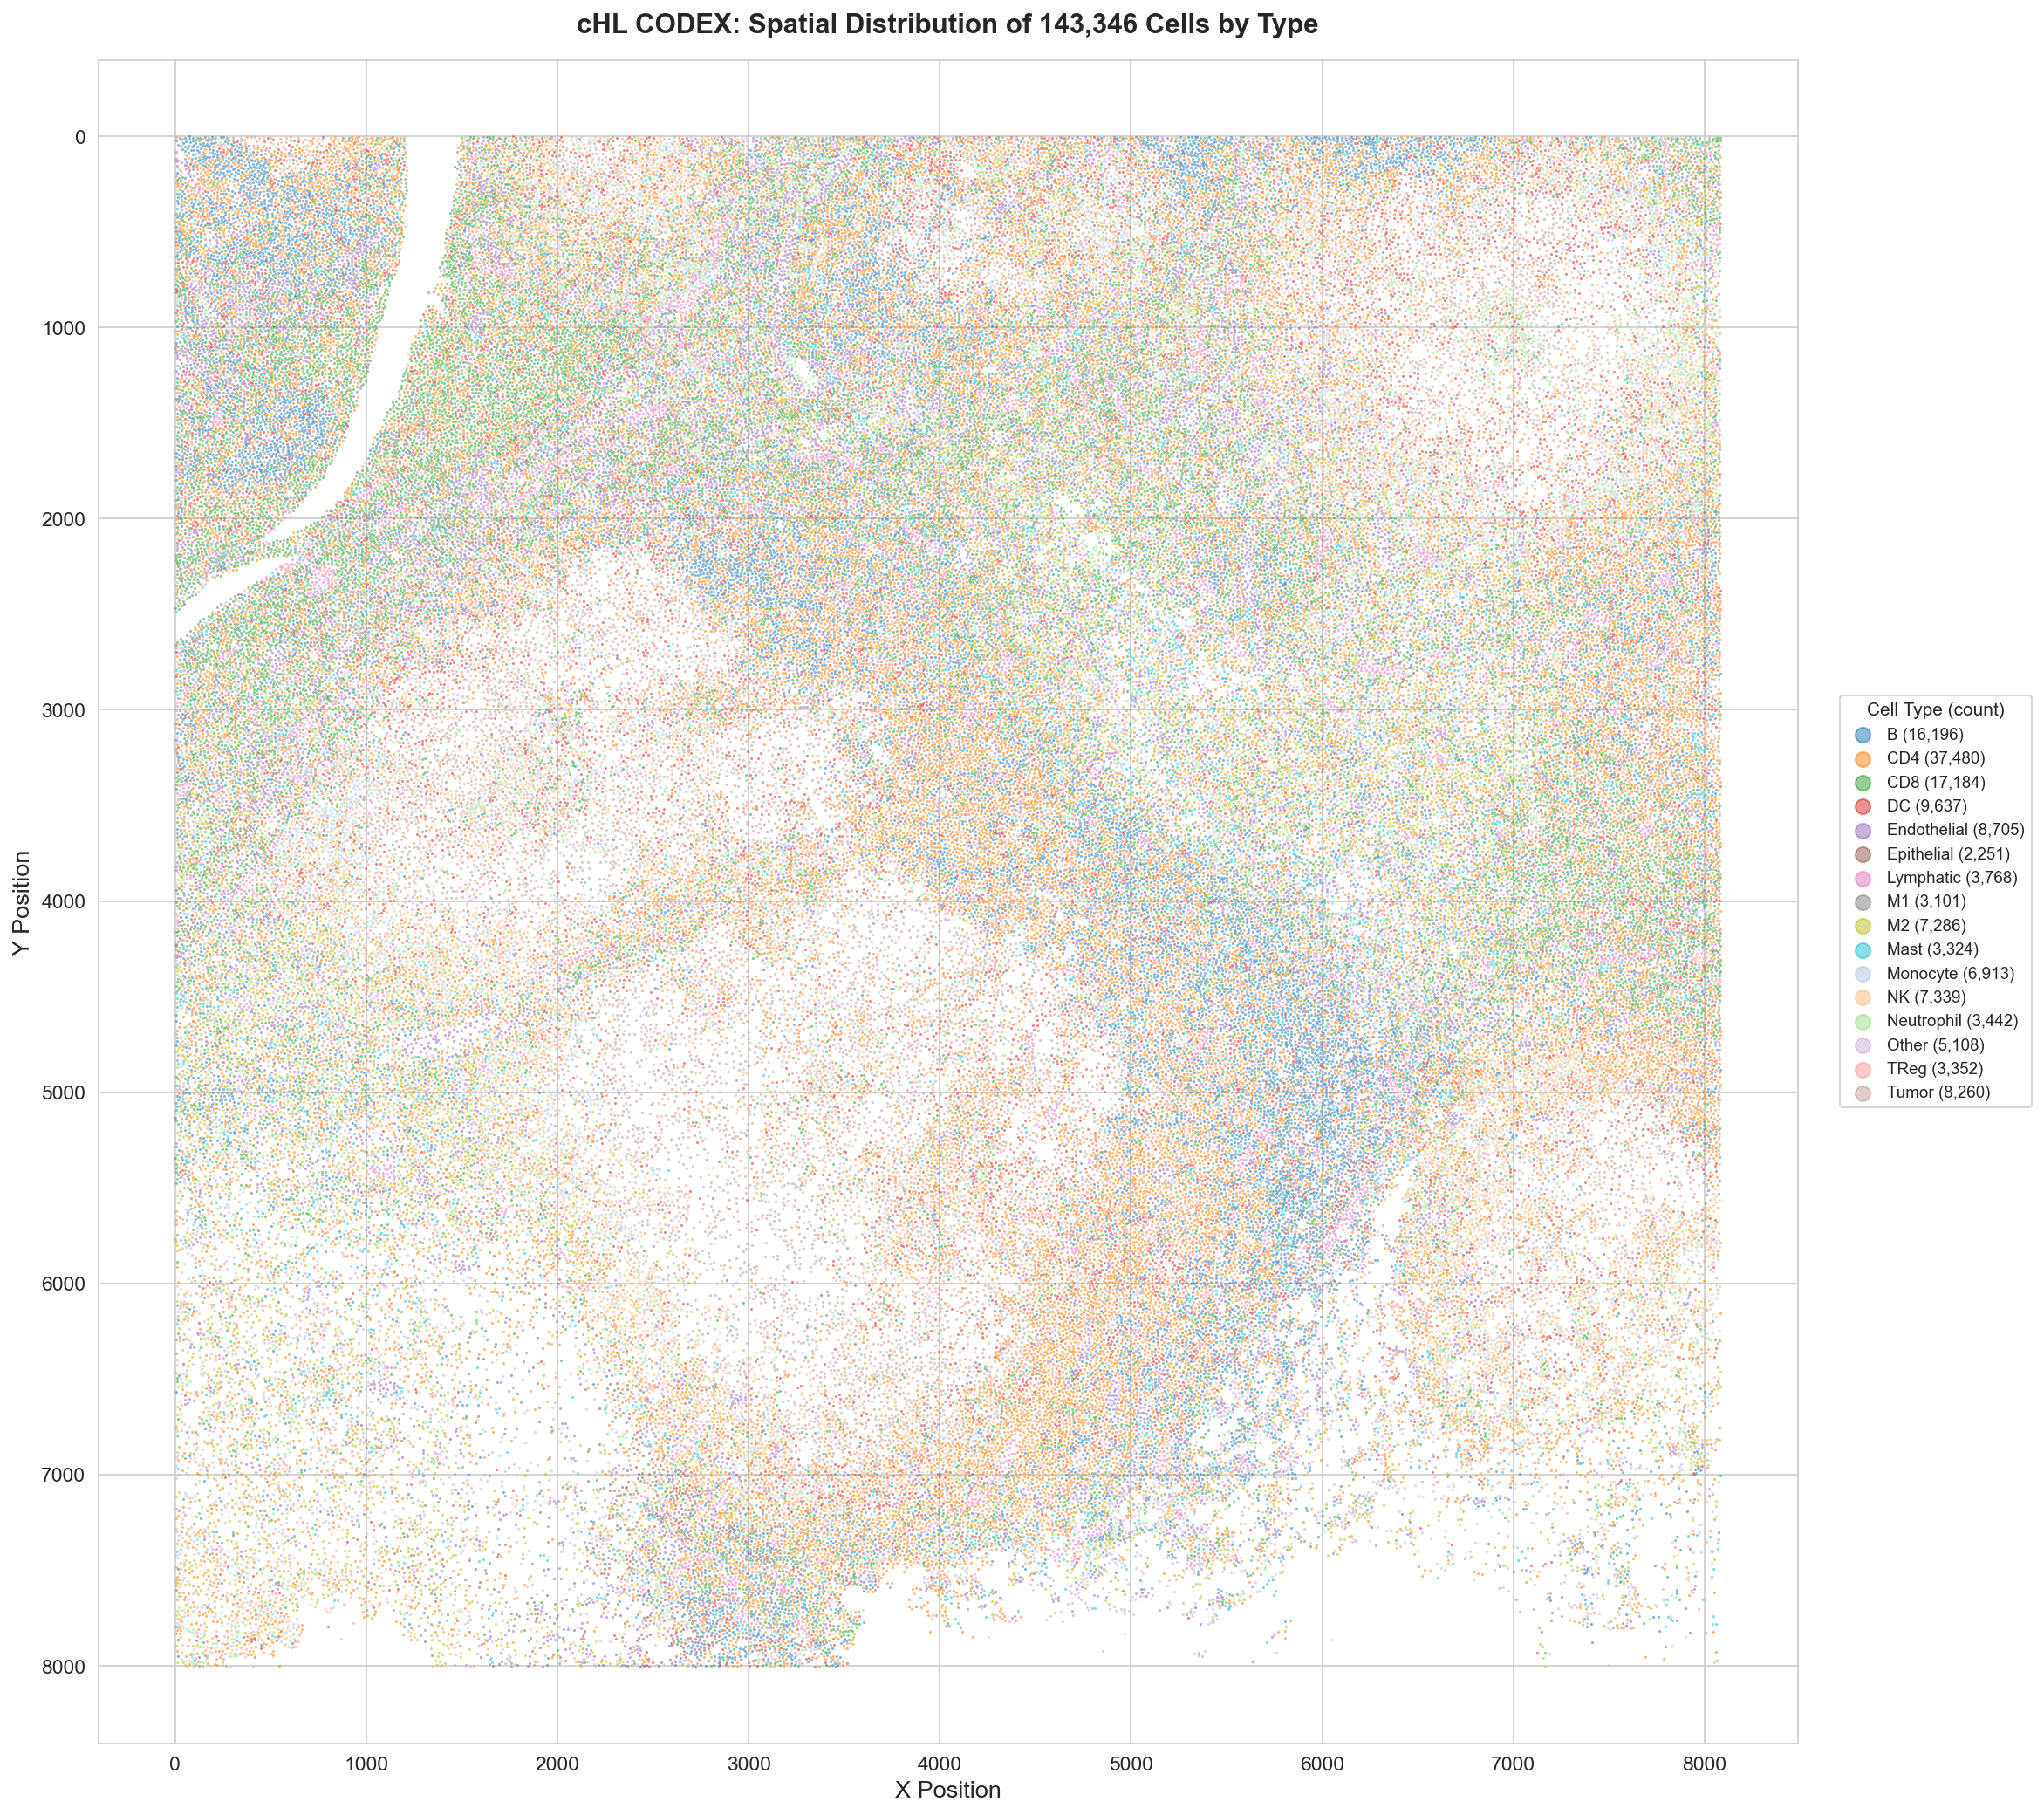

Saved: figures_spatial_cell_map.png


In [10]:
# Color palette — 16 distinguishable colours
palette = {
    'B':           '#1f77b4',  # blue
    'CD4':         '#ff7f0e',  # orange
    'CD8':         '#2ca02c',  # green
    'DC':          '#d62728',  # red
    'Endothelial': '#9467bd',  # purple
    'Epithelial':  '#8c564b',  # brown
    'Lymphatic':   '#e377c2',  # pink
    'M1':          '#7f7f7f',  # grey
    'M2':          '#bcbd22',  # olive
    'Mast':        '#17becf',  # cyan
    'Monocyte':    '#aec7e8',  # light blue
    'NK':          '#ffbb78',  # light orange
    'Neutrophil':  '#98df8a',  # light green
    'Other':       '#c5b0d5',  # lavender
    'TReg':        '#ff9896',  # light red
    'Tumor':       '#c49c94',  # tan
}

fig, ax = plt.subplots(figsize=(16, 14))

# Plot each class separately for legend ordering
for ct in CLASS_NAMES:
    subset = df[df['cellType'] == ct]
    ax.scatter(subset['X_cent'], subset['Y_cent'],
               c=palette[ct], label=f'{ct} ({len(subset):,})',
               s=0.3, alpha=0.5, rasterized=True)

ax.set_xlabel('X Position', fontsize=13)
ax.set_ylabel('Y Position', fontsize=13)
ax.set_title('cHL CODEX: Spatial Distribution of 143,346 Cells by Type',
             fontsize=15, fontweight='bold', pad=15)
ax.set_aspect('equal')
ax.invert_yaxis()  # Image convention: origin at top-left

# Legend outside the plot
legend = ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                   fontsize=9, markerscale=15, frameon=True,
                   title='Cell Type (count)', title_fontsize=10,
                   ncol=1, handletextpad=0.5)

plt.tight_layout()
plt.savefig('figures_spatial_cell_map.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures_spatial_cell_map.png')

## 4. Summary

| Method | Weighted F1 | vs 90% Target |
|--------|-------------|---------------|
| ASTIR | 61.0% | -29.0pp |
| CellSighter | 82.0% | -8.0pp |
| MAPS (5-fold ensemble) | 89.7% | -0.3pp |
| **Ours (Stacking Ensemble)** | **90.27%** | **+0.27pp** |

Our stacking ensemble combines 4 diverse base models (MLP + 3 Optuna-tuned GBDTs) through a Logistic Regression meta-learner that learns class-specific model trust, achieving the first result to surpass the 90% weighted F1 threshold on cHL CODEX cross-validation.